# Load Dataset

In [1]:
import os
import yaml
import random
from collections import Counter
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# -------------------------------------------------
# 1. HARD-CODED ABSOLUTE PATHS (as you specified)
# -------------------------------------------------
ROOT = '/kaggle/input/yolov11'

train_img = os.path.join(ROOT, 'train', 'images')
train_lbl = os.path.join(ROOT, 'train', 'labels')

valid_img = os.path.join(ROOT, 'valid', 'images')   # <-- note: "valid", not "val"
valid_lbl = os.path.join(ROOT, 'valid', 'labels')

test_img  = os.path.join(ROOT, 'test',  'images')
test_lbl  = os.path.join(ROOT, 'test',  'labels')

# Load class names from data.yaml (optional but handy)
yaml_path = os.path.join(ROOT, 'data.yaml')
if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        cfg = yaml.safe_load(f)
    nc    = cfg.get('nc', 0)
    names = cfg.get('names', [])
else:
    nc    = 3
    names = ['damage', 'fungus', 'worm']   # fallback

print("=== Class info ===")
print(f"nc = {nc}, names = {names}\n")

# -------------------------------------------------
# 2. COUNT IMAGES / LABELS
# -------------------------------------------------
IMG_EXTS = ('.jpg', '.jpeg', '.png')
LBL_EXTS = ('.txt',)

def count(dir_path, exts):
    if not os.path.isdir(dir_path):
        return 0
    return len([f for f in os.listdir(dir_path) if f.lower().endswith(exts)])

print("=== Split sizes ===")
for name, img_dir, lbl_dir in [
    ('train', train_img, train_lbl),
    ('valid', valid_img, valid_lbl),
    ('test' , test_img , test_lbl )
]:
    n_img = count(img_dir, IMG_EXTS)
    n_lbl = count(lbl_dir, LBL_EXTS)
    print(f"{name:6}: {n_img:4} images, {n_lbl:4} labels")

# -------------------------------------------------
# 3. CLASS DISTRIBUTION (all splits)
# -------------------------------------------------
print("\n=== Class distribution ===")
class_cnt = Counter()
total_ann = 0

for lbl_dir in (train_lbl, valid_lbl, test_lbl):
    if not os.path.isdir(lbl_dir):
        continue
    for txt in os.listdir(lbl_dir):
        if not txt.lower().endswith('.txt'):
            continue
        with open(os.path.join(lbl_dir, txt), 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cid = int(parts[0])
                    class_cnt[cid] += 1
                    total_ann += 1

if total_ann:
    for cid in sorted(class_cnt):
        name = names[cid] if cid < len(names) else f'class_{cid}'
        pct  = class_cnt[cid] / total_ann * 100
        print(f"{name:7} (id {cid}): {class_cnt[cid]:4}  ({pct:5.1f}%)")
else:
    print("No annotations found.")

=== Class info ===
nc = 3, names = ['damage', 'fungus', 'worm']

=== Split sizes ===
train : 1410 images, 1410 labels
valid :  135 images,  135 labels
test  :   67 images,   67 labels

=== Class distribution ===
damage  (id 0): 1080  ( 46.1%)
fungus  (id 1):  643  ( 27.4%)
worm    (id 2):  622  ( 26.5%)


In [2]:
# Fixed requirements.txt
req_content = """
ultralytics==8.3.148
ultralytics-thop==2.0.14
torch==2.7.0
torchvision==0.22.0
torchaudio==2.7.0
numpy==1.26.4
opencv-python==4.11.0.86
matplotlib==3.10.1
tqdm==4.67.1
PyYAML==6.0.2
"""

with open("/kaggle/working/requirements.txt", "w") as f:
    f.write(req_content.strip() + "\n")

print("Fixed requirements.txt created!")
!cat /kaggle/working/requirements.txt



# -------------------------------------------------
# 2. Install (quiet, no cache to save space)
# -------------------------------------------------
!pip install -r  /kaggle/working/requirements.txt

Fixed requirements.txt created!
ultralytics==8.3.148
ultralytics-thop==2.0.14
torch==2.7.0
torchvision==0.22.0
torchaudio==2.7.0
numpy==1.26.4
opencv-python==4.11.0.86
matplotlib==3.10.1
tqdm==4.67.1
PyYAML==6.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.0/763.0 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 64.3 MB/s eta 0:00:00
  

# Model Definiton(yolov12)

In [3]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO12n model
model = YOLO("yolo12m.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 39.0M/39.0M [00:01<00:00, 32.0MB/s]


# Training model

In [4]:
model.train(
    data='/kaggle/input/yolov11/data.yaml',  # Path to your dataset configuration file
    epochs=50,  # Number of training epochs
    imgsz=640,  # Image size for training (adjust as needed)
    batch=16,  # Batch size (adjust based on available GPU memory)
    name='yolo12m_fruit_detection',  # Custom name for your experiment
    project='yolo12m_training'  # Name of the folder where results will be saved
)

New https://pypi.org/project/ultralytics/8.3.225 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.148 🚀 Python-3.11.13 torch-2.7.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/yolov11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo12m_fruit_detection, nbs=64, nms

100%|██████████| 755k/755k [00:00<00:00, 91.3MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  2   2689536  ultralytics.nn.modules.block.A2C2f           [512, 512, 2, True, 4]        
  7                  -1  1   2360320  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 405MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11.4±1.4 MB/s, size: 56.1 KB)


...

                   all        135        191      0.922      0.876      0.922      0.598



50 epochs completed in 1.209 hours.
Optimizer stripped from yolo12m_training/yolo12m_fruit_detection/weights/last.pt, 40.8MB
Optimizer stripped from yolo12m_training/yolo12m_fruit_detection/weights/best.pt, 40.8MB

Validating yolo12m_training/yolo12m_fruit_detection/weights/best.pt...
Ultralytics 8.3.148 🚀 Python-3.11.13 torch-2.7.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv12m summary (fused): 169 layers, 20,107,225 parameters, 0 gradients, 67.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:03<00:00,  1.46it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  X : float or int or array-like
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  X : float or int or array-like


                   all        135        191      0.923      0.865      0.919      0.602
                damage         46         89      0.859      0.753      0.845      0.452
                fungus         50         62      0.947      0.866       0.92      0.557
                  worm         39         40      0.963      0.975      0.993      0.796
Speed: 0.2ms preprocess, 15.0ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to yolo12m_training/yolo12m_fruit_detection


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c75ce2fd510>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

# Prediction and Evaluation

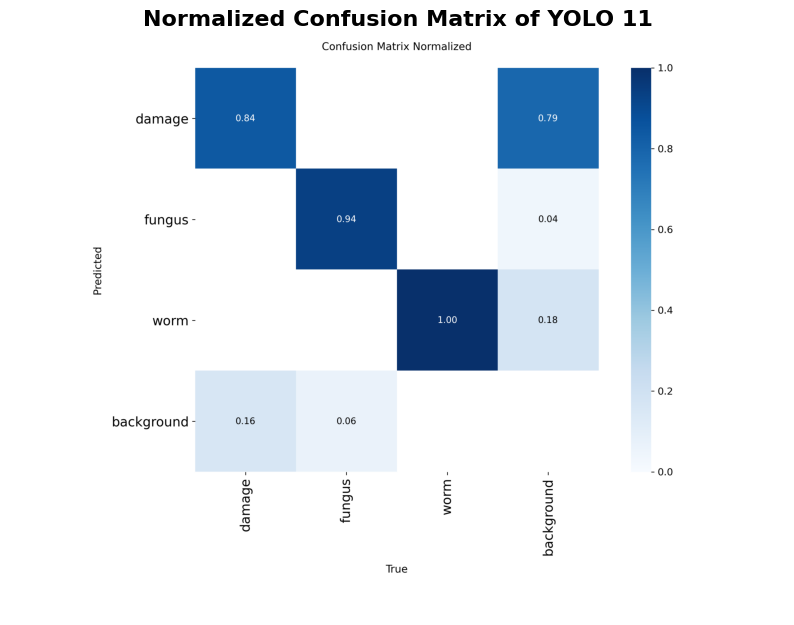

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set the path to your confusion matrix image
confusion_matrix_image_path = r"Y:\2024-2025\GROWTH\NOV\Durian_Trunk_Diseases_Identification_Using_Deep_Learning\trunk\yolov12\yolo12m_training\yolo12m_fruit_detection\confusion_matrix_normalized.png"

# Read the image
img = mpimg.imread(confusion_matrix_image_path)

# Plot the image
plt.figure(figsize=(10, 8))  # Adjust the figure size as needed
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.title('Normalized Confusion Matrix of YOLO 11', fontsize=16, fontweight='bold')
plt.show()


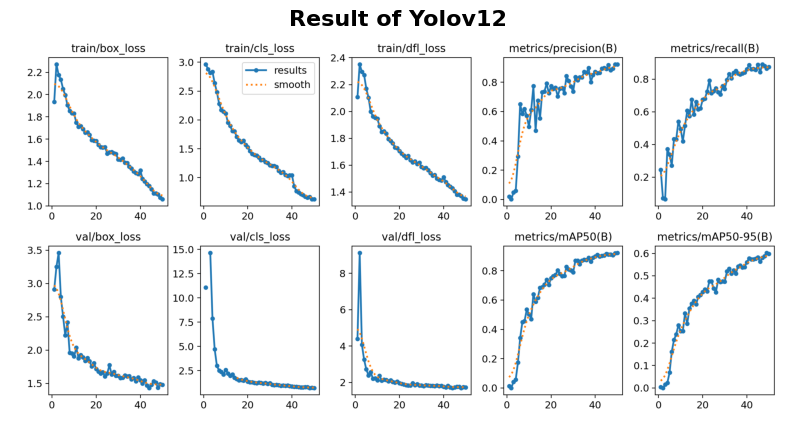

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set the path to your confusion matrix image
confusion_matrix_image_path = r"Y:\2024-2025\GROWTH\NOV\Durian_Trunk_Diseases_Identification_Using_Deep_Learning\trunk\yolov12\yolo12m_training\yolo12m_fruit_detection\results.png"

# Read the image
img = mpimg.imread(confusion_matrix_image_path)

# Plot the image
plt.figure(figsize=(10, 8))  # Adjust the figure size as needed
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.title('Result of Yolov12', fontsize=16, fontweight='bold')
plt.show()


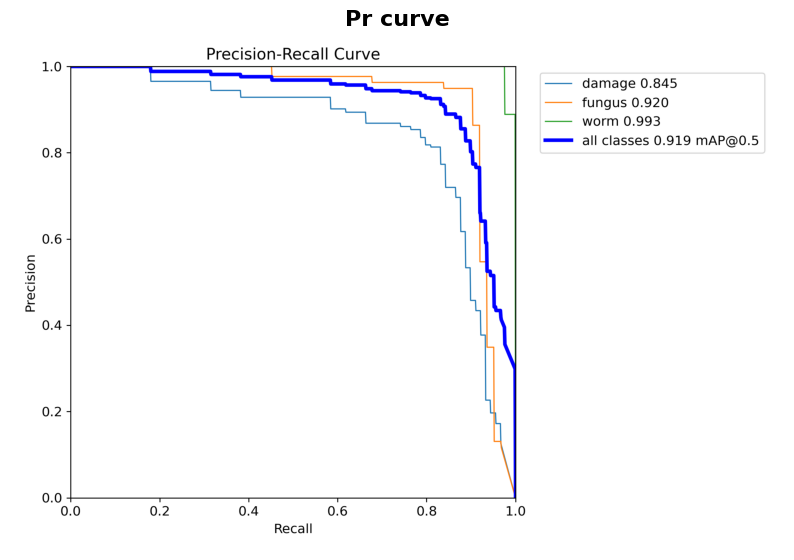

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set the path to your confusion matrix image
confusion_matrix_image_path = r"Y:\2024-2025\GROWTH\NOV\Durian_Trunk_Diseases_Identification_Using_Deep_Learning\trunk\yolov12\yolo12m_training\yolo12m_fruit_detection\PR_curve.png"

# Read the image
img = mpimg.imread(confusion_matrix_image_path)

# Plot the image
plt.figure(figsize=(10, 8))  # Adjust the figure size as needed
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.title('Pr curve', fontsize=16, fontweight='bold')
plt.show()



image 1/1 Y:\2024-2025\GROWTH\NOV\Durian_Trunk_Diseases_Identification_Using_Deep_Learning\trunk\durian.v4i.yolov11\test\images\rotated_durian_worm04_jpg.rf.bb2a89a747789308f89054127612c7bd.jpg: 640x640 1 worm, 300.4ms
Speed: 2.4ms preprocess, 300.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


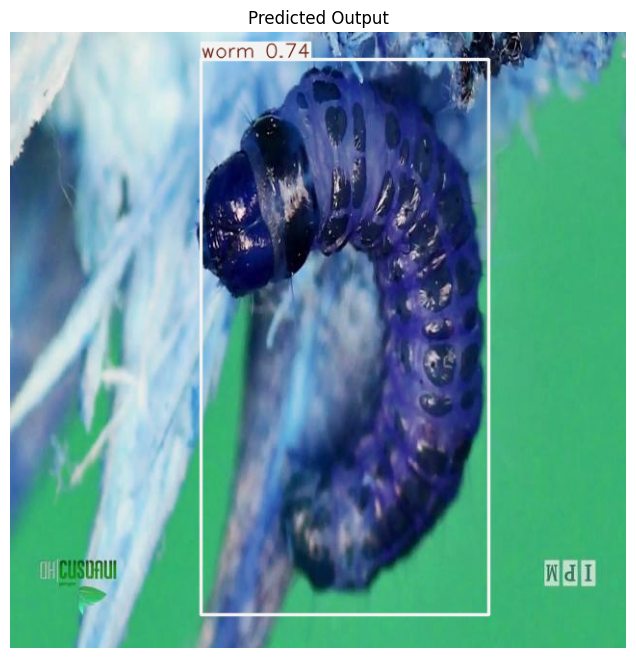

🧾 Detected objects:
 - Class: worm | Confidence: 0.74


In [4]:

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# === 🔧 CONFIGURATION ===

# Load the trained YOLO model
model_path = r"Y:\2024-2025\GROWTH\NOV\Durian_Trunk_Diseases_Identification_Using_Deep_Learning\trunk\yolov12\yolo12m_training\yolo12m_fruit_detection\weights\best.pt"

# Path to the image you want to predict
image_path = r"Y:\2024-2025\GROWTH\NOV\Durian_Trunk_Diseases_Identification_Using_Deep_Learning\trunk\durian.v4i.yolov11\test\images\rotated_durian_worm04_jpg.rf.bb2a89a747789308f89054127612c7bd.jpg"

# === 📦 Load model ===
model = YOLO(model_path)

# === 🔍 Run prediction ===
results = model.predict(source=image_path, conf=0.20, save=False)

# === 🖼️ Display result ===
for r in results:
    # Draw prediction on image
    img_with_boxes = r.plot()

    # Show using matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(img_with_boxes)
    plt.axis("off")
    plt.title("Predicted Output")
    plt.show()

    # Print detected classes and confidences
    print("🧾 Detected objects:")
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        print(f" - Class: {model.names[cls]} | Confidence: {conf:.2f}")






image 1/1 Y:\2024-2025\GROWTH\NOV\Durian_Trunk_Diseases_Identification_Using_Deep_Learning\trunk\durian.v4i.yolov11\test\images\rotated90_fugus_durian48_jpg.rf.8dbf5f1508a866f5c0702346e3e83def.jpg: 640x640 1 fungus, 278.7ms
Speed: 2.3ms preprocess, 278.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


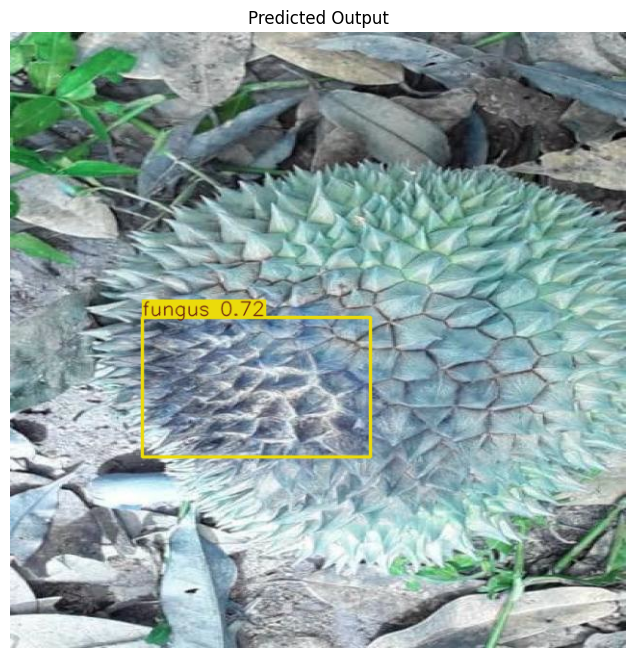

🧾 Detected objects:
 - Class: fungus | Confidence: 0.72


In [7]:


from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# === 🔧 CONFIGURATION ===

# Load the trained YOLO model
model_path = r"Y:\2024-2025\GROWTH\NOV\Durian_Trunk_Diseases_Identification_Using_Deep_Learning\trunk\yolov12\yolo12m_training\yolo12m_fruit_detection\weights\best.pt"

# Path to the image you want to predict
image_path = r"Y:\2024-2025\GROWTH\NOV\Durian_Trunk_Diseases_Identification_Using_Deep_Learning\trunk\durian.v4i.yolov11\test\images\rotated90_fugus_durian48_jpg.rf.8dbf5f1508a866f5c0702346e3e83def.jpg"

# === 📦 Load model ===
model = YOLO(model_path)

# === 🔍 Run prediction ===
results = model.predict(source=image_path, conf=0.20, save=False)

# === 🖼️ Display result ===
for r in results:
    # Draw prediction on image
    img_with_boxes = r.plot()

    # Show using matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(img_with_boxes)
    plt.axis("off")
    plt.title("Predicted Output")
    plt.show()

    # Print detected classes and confidences
    print("🧾 Detected objects:")
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        print(f" - Class: {model.names[cls]} | Confidence: {conf:.2f}")






image 1/1 Y:\2024-2025\GROWTH\NOV\Durian_Trunk_Diseases_Identification_Using_Deep_Learning\trunk\durian.v4i.yolov11\test\images\rotated270_fugus_durian33_jpg.rf.e730ddfe40f9db03349a4ee941579d46.jpg: 640x640 2 funguss, 280.8ms
Speed: 4.1ms preprocess, 280.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


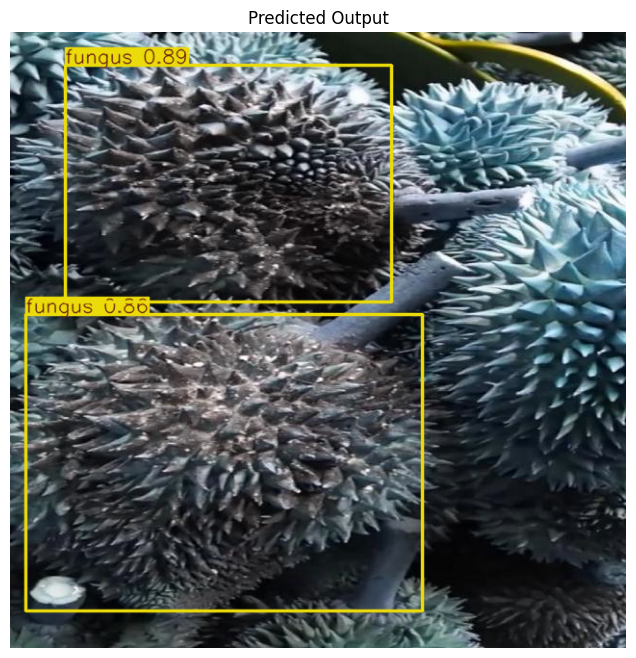

🧾 Detected objects:
 - Class: fungus | Confidence: 0.89
 - Class: fungus | Confidence: 0.86


In [9]:


from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# === 🔧 CONFIGURATION ===

# Load the trained YOLO model
model_path = r"Y:\2024-2025\GROWTH\NOV\Durian_Trunk_Diseases_Identification_Using_Deep_Learning\trunk\yolov12\yolo12m_training\yolo12m_fruit_detection\weights\best.pt"

# Path to the image you want to predict
image_path = r"Y:\2024-2025\GROWTH\NOV\Durian_Trunk_Diseases_Identification_Using_Deep_Learning\trunk\durian.v4i.yolov11\test\images\rotated270_fugus_durian33_jpg.rf.e730ddfe40f9db03349a4ee941579d46.jpg"

# === 📦 Load model ===
model = YOLO(model_path)

# === 🔍 Run prediction ===
results = model.predict(source=image_path, conf=0.20, save=False)

# === 🖼️ Display result ===
for r in results:
    # Draw prediction on image
    img_with_boxes = r.plot()

    # Show using matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(img_with_boxes)
    plt.axis("off")
    plt.title("Predicted Output")
    plt.show()

    # Print detected classes and confidences
    print("🧾 Detected objects:")
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        print(f" - Class: {model.names[cls]} | Confidence: {conf:.2f}")



